In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("bank.csv")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.shape

(11162, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [9]:
for col in df.columns:
    print(df[col].value_counts(dropna=False))

age
31    496
32    477
34    466
33    464
35    461
     ... 
92      2
93      2
88      2
95      1
89      1
Name: count, Length: 76, dtype: int64
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
default
no     10994
yes      168
Name: count, dtype: int64
balance
 0       774
 1        39
 3        35
 2        34
 4        29
        ... 
 5517      1
 8332      1
 4859      1
-267       1
-134       1
Name: count, Length: 3805, dtype: int64
housing
no     5881
yes    5281
Name: count, dtype: int64
loan
no     9702
yes    1460
Name: count, dtype: int

In [10]:
df[["default","housing","loan","deposit"]]=(df[["default","housing","loan","deposit"]]=="yes").astype(int)

In [11]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,0,1,1,0,cellular,20,apr,257,1,-1,0,unknown,0
11158,39,services,married,secondary,0,733,0,0,unknown,16,jun,83,4,-1,0,unknown,0
11159,32,technician,single,secondary,0,29,0,0,cellular,19,aug,156,2,-1,0,unknown,0
11160,43,technician,married,secondary,0,0,0,1,cellular,8,may,9,2,172,5,failure,0


In [12]:
#for col in df.columns:
 #   print(df[col].value_counts()) 

In [13]:
df=pd.get_dummies(df,columns=["job","marital","education","contact","month","poutcome"],dtype=int)

In [14]:
df

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1042,1,-1,0,...,0,0,1,0,0,0,0,0,0,1
1,56,0,45,0,0,5,1467,1,-1,0,...,0,0,1,0,0,0,0,0,0,1
2,41,0,1270,1,0,5,1389,1,-1,0,...,0,0,1,0,0,0,0,0,0,1
3,55,0,2476,1,0,5,579,1,-1,0,...,0,0,1,0,0,0,0,0,0,1
4,54,0,184,0,0,5,673,2,-1,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,0,1,1,0,20,257,1,-1,0,...,0,0,0,0,0,0,0,0,0,1
11158,39,0,733,0,0,16,83,4,-1,0,...,1,0,0,0,0,0,0,0,0,1
11159,32,0,29,0,0,19,156,2,-1,0,...,0,0,0,0,0,0,0,0,0,1
11160,43,0,0,0,1,8,9,2,172,5,...,0,0,1,0,0,0,1,0,0,0


In [15]:
# Train-test split and model selection
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score,StratifiedKFold


# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve


# Pipeline
from sklearn.pipeline import Pipeline

# Feature importance
from sklearn.inspection import permutation_importance

# For plotting decision trees in the forest
from sklearn.tree import plot_tree

In [16]:
#there is data leakage,for betterment of model dro

In [17]:
X = df.drop(["deposit"], axis=1)
y = df["deposit"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
pipe=Pipeline([("model",RandomForestClassifier(random_state=42))])

In [19]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
grid=GridSearchCV(pipe,param_grid,scoring=scoring,refit="accuracy",n_jobs=-1,cv=skf)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'accuracy'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [20]:
y_pred=grid.predict(X_test)

In [21]:
accuracy_score(y_test,y_pred)

0.8351992834751455

In [22]:
precision_score(y_test,y_pred)

0.8084730803177406

In [23]:
f1_score(y_test,y_pred)

0.8327272727272728

In [24]:
recall_score(y_test,y_pred)

0.8584817244611059

In [25]:
confusion_matrix(y_test,y_pred)

array([[949, 217],
       [151, 916]])

In [26]:
pd.DataFrame(classification_report(y_test,y_pred,output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.862727,0.808473,0.835199,0.835600,0.836803
recall,0.813894,0.858482,0.835199,0.836188,0.835199
f1-score,0.837599,0.832727,0.835199,0.835163,0.835271
support,1166.000000,1067.000000,0.835199,2233.000000,2233.000000


In [27]:
roc_auc_score(y_test,y_pred)

0.8361876889887006

In [28]:
roc_curve(y_test,y_pred)

(array([0.        , 0.18610635, 1.        ]),
 array([0.        , 0.85848172, 1.        ]),
 array([inf,  1.,  0.]))

In [29]:
accuracy_score(y_train,grid.predict(X_train))

1.0

In [30]:
accuracy_score(y_test,grid.predict(X_test))

0.8351992834751455

In [31]:
best_model = grid.best_estimator_.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(20))

               Feature  Importance
6             duration    0.331386
2              balance    0.077545
0                  age    0.075024
5                  day    0.066322
7             campaign    0.035009
8                pdays    0.031987
46    poutcome_success    0.030924
31     contact_unknown    0.025315
3              housing    0.024958
9             previous    0.021328
29    contact_cellular    0.016877
40           month_may    0.013067
39           month_mar    0.012900
32           month_apr    0.012695
47    poutcome_unknown    0.012317
42           month_oct    0.011518
38           month_jun    0.010731
4                 loan    0.010621
33           month_aug    0.009948
27  education_tertiary    0.009865


In [32]:
y_proba=grid.predict_proba(X_test)[:,1]

In [33]:
roc_auc_score(y_test,y_proba)

0.913512501185575

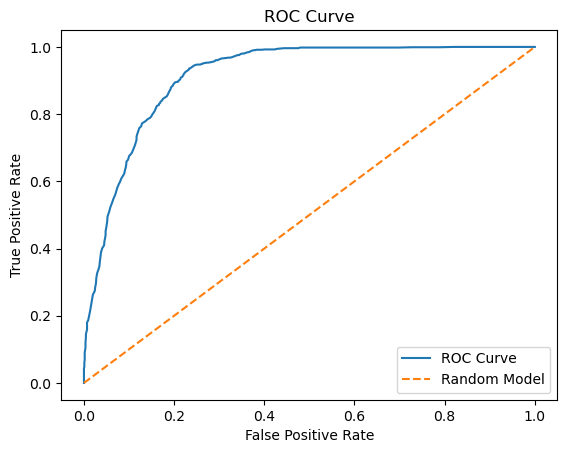

In [34]:
y_proba = grid.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

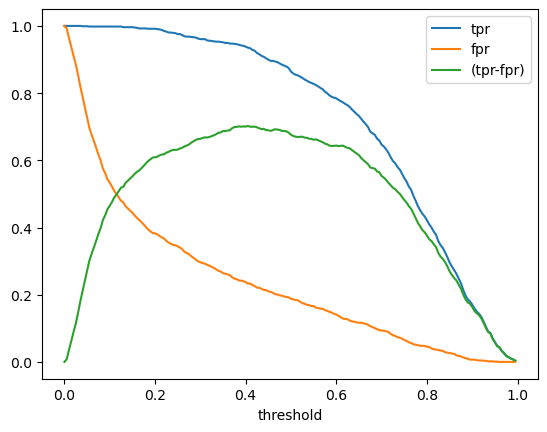

In [35]:
plt.plot(thresholds,tpr,label="tpr")
plt.plot(thresholds,fpr,label="fpr")
plt.plot(thresholds,tpr-fpr,label="(tpr-fpr)")
plt.xlabel("threshold")
plt.legend()

In [36]:
j=tpr-fpr
j

array([0.        , 0.00374883, 0.00749766, 0.01030928, 0.01780694,
       0.0262418 , 0.03280225, 0.04311153, 0.04693993, 0.05818642,
       0.06857527, 0.08450779, 0.08919383, 0.10153667, 0.11653198,
       0.12973245, 0.13910453, 0.14480734, 0.15152694, 0.16371063,
       0.1730827 , 0.17707026, 0.18660147, 0.2008983 , 0.21800675,
       0.24269244, 0.24965076, 0.2591024 , 0.26957083, 0.28464572,
       0.29698856, 0.30667893, 0.31339853, 0.32472458, 0.34175346,
       0.3502679 , 0.35987869, 0.3649626 , 0.37628866, 0.38581988,
       0.3924599 , 0.40370639, 0.41417482, 0.42839207, 0.44252975,
       0.45604852, 0.46370533, 0.47441248, 0.48214886, 0.49098159,
       0.50059239, 0.50637478, 0.51419073, 0.51817828, 0.52599424,
       0.5331117 , 0.54170572, 0.54842532, 0.55319093, 0.56451698,
       0.5667097 , 0.57538328, 0.57663879, 0.57875192, 0.58852187,
       0.59438383, 0.60016622, 0.60688582, 0.61532068, 0.62008629,
       0.62977666, 0.63555905, 0.63689413, 0.63978533, 0.64361

In [37]:
best_index=j.argmax()
best_threshold=thresholds[best_index]
print(best_threshold)

0.405


In [38]:
j[best_index]

np.float64(0.7020565507241252)

In [39]:
tpr[best_index]

np.float64(0.9353327085285849)

In [40]:
fpr[best_index]

np.float64(0.2332761578044597)

In [41]:
y_pred=(y_proba>=best_threshold).astype(int)

In [42]:
accuracy_score(y_test,y_pred)

0.8472906403940886

In [43]:
precision_score(y_test,y_pred)

0.7858267716535433

In [44]:
recall_score(y_test,y_pred)

0.9353327085285849

In [45]:
f1_score(y_test,y_pred)

0.8540864356011981

In [46]:
confusion_matrix(y_test,y_pred)

array([[894, 272],
       [ 69, 998]])

In [47]:
pd.DataFrame(classification_report(y_test,y_pred,output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.928349,0.785827,0.847291,0.857088,0.860247
recall,0.766724,0.935333,0.847291,0.851028,0.847291
f1-score,0.839831,0.854086,0.847291,0.846959,0.846643
support,1166.000000,1067.000000,0.847291,2233.000000,2233.000000


In [48]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1])

best_idx = f1_scores.argmax()

best_threshold = thresholds[best_idx]

print(best_threshold)

0.385


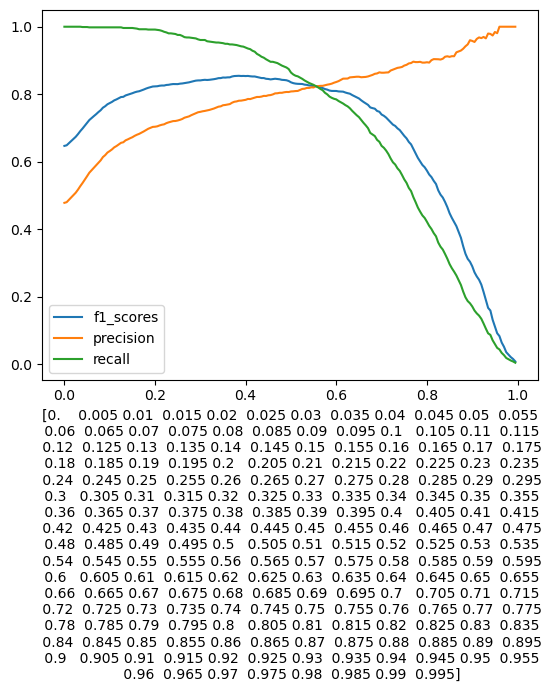

In [49]:
plt.plot(thresholds,f1_scores,label="f1_scores")
plt.plot(thresholds,precision[:-1],label="precision")
plt.plot(thresholds,recall[:-1],label="recall")
plt.legend()
plt.xlabel(thresholds)
plt.show()

In [50]:
f1_scores[best_idx]

np.float64(0.8544760288502333)

In [51]:
y_pred1=(y_proba>=best_threshold).astype(int)

In [52]:
accuracy_score(y_test,y_pred1)

0.8463949843260188

In [53]:
precision_score(y_test,y_pred1)

0.7806201550387597

In [54]:
recall_score(y_test,y_pred1)

0.943767572633552

In [55]:
f1_score(y_test,y_pred1)

0.8544760288502333

In [56]:
confusion_matrix(y_test,y_pred1)

array([[ 883,  283],
       [  60, 1007]])

In [57]:
pd.DataFrame(classification_report(y_test,y_pred1,output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.936373,0.780620,0.846395,0.858497,0.861949
recall,0.757290,0.943768,0.846395,0.850529,0.846395
f1-score,0.837364,0.854476,0.846395,0.845920,0.845541
support,1166.000000,1067.000000,0.846395,2233.000000,2233.000000


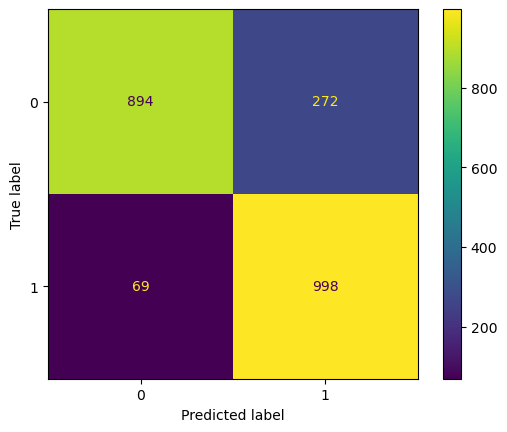

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

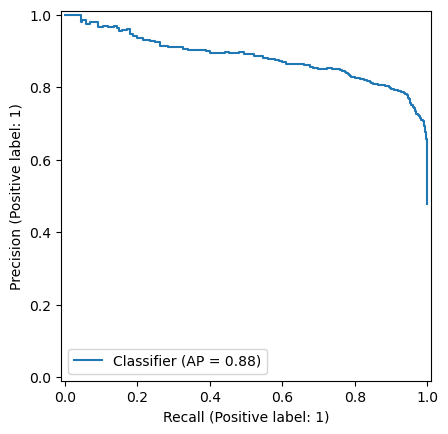

In [59]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)

In [60]:
from sklearn.utils import all_estimators

models = all_estimators()

In [61]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    grid,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)